## Python Project: Diabetes Hospital Stay Analysis
Objective: Analyze whether there are differences in hospital stay length
between male and female patients with diabetes.

In [44]:
!mamba install pandas numpy matplotlib seaborn scikit-learn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.17 seconds
All requested packages already installed.


In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [46]:
df = pd.read_csv('https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv')

In [47]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [48]:
df['gender'].value_counts(dropna=False)

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

## Data Cleaning

In [49]:
# Select relevant columns
df1 = df[['gender', 'time_in_hospital']].copy()

In [50]:
# remove Unknown/Invalid genders
df1 = df1[df1['gender'].isin(['Male', 'Female'])]

In [51]:
df1.info()
# No missing values found, so no need to drop rows for missing data

<class 'pandas.DataFrame'>
Index: 101763 entries, 0 to 101765
Data columns (total 2 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   gender            101763 non-null  str  
 1   time_in_hospital  101763 non-null  int64
dtypes: int64(1), str(1)
memory usage: 1.9 MB


## Descriptive Statistics

- Mean: Female (4.48) vs Male (4.30)
- Median: Female (4) vs Male (3)
- Standard deviation: Similar for both groups (~2.98)

In [52]:
df1.groupby('gender')['time_in_hospital'].describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
Female,54708.0,4.478797,2.980388,1.0,2.0,4.0,6.0,14.0
Male,47055.0,4.299777,2.987703,1.0,2.0,3.0,6.0,14.0


In [53]:
df1.groupby('gender')['time_in_hospital'].median()

gender
Female    4.0
Male      3.0
Name: time_in_hospital, dtype: float64

## Visualization

In [54]:
palette = {
    'Female': '#ffb482',  # orange
    'Male': '#a1c9f4'     # blue
}

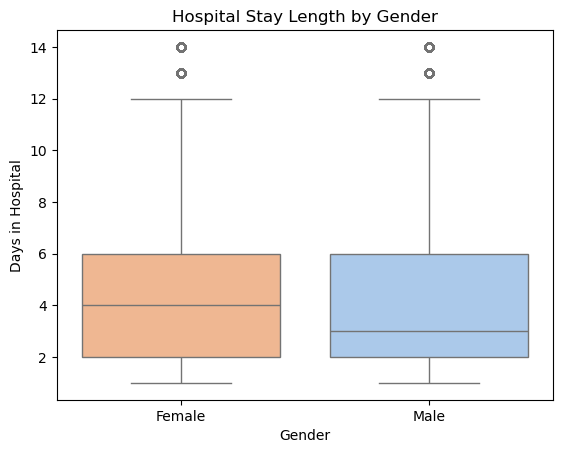

In [55]:
# Boxplot (Distribution Comparison)
sns.boxplot(
    data=df1,
    x='gender',
    y='time_in_hospital',
    hue='gender',
    palette=palette,
    legend=False
)

plt.title("Hospital Stay Length by Gender")
plt.xlabel("Gender")
plt.ylabel("Days in Hospital")
plt.show()

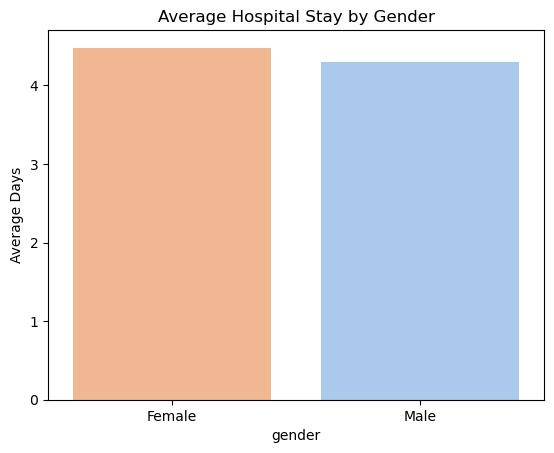

In [56]:
# Bar Plot (Mean Comparison)
avg_stay = df1.groupby('gender', as_index=False)['time_in_hospital'].mean()

sns.barplot(
    data=avg_stay,
    x='gender',
    y='time_in_hospital',
    hue='gender',
    palette=palette,
    legend=False
)
plt.title("Average Hospital Stay by Gender")
plt.ylabel("Average Days")
plt.show()

## Conclusion

- Female patients have a slightly higher average and median hospital stay than male patients.  
- The difference between the two groups is small.  
- Both groups show similar variability and overlapping distributions.  

Overall, these results suggest that gender has minimal impact on hospital stay duration in this dataset.